In [2]:
import Pkg;
Pkg.activate(".");
import Plots;
import StatsPlots
using Distributions: Uniform
using BenchmarkTools: @benchmark

  Activating project at `~/juliacon`


# Compute π via monte carlo experiment

In [2]:
N=1000
function compute_pi_record()
  tries = zeros(N,2)
  hits = 0
  for i = 1:N
    x, y = rand(Uniform(-1,1), 2)
    tries[i,1] = x
    tries[i,2] = y
    if sqrt(x^2 + y^2) <= 1.0
      hits += 1
    end
  end
  return (4.0 * hits / N, tries)
end
function approx(points)
    hits = mapslices(x->(sqrt(x[1]^2 + x[2]^2)<=1.0)  ,  points; dims=2)
    return 4.0 * sum(hits) / length(hits)
end
res,results = compute_pi_record()
appr = [approx(results[1:i,:]) for i in 1:1000];

In [3]:
anim = Plots.@animate for i in 1:10:1000
    Plots.closeall()
    p1 = Plots.plot(1,2, label="")
    p2 = Plots.plot(2,1, ylim=[2,4], xlim=[1,1000], label="")
    
    Plots.plot!(p1, Plots.partialcircle(0, 2*pi, 40), color=:red, label="")
    Plots.scatter!(p1, results[1:i,1], results[1:i,2], label="")
    Plots.plot!(p2, [1,1000], [pi,pi], color=:red, label="π")
    Plots.plot!(p2, 1:i, appr[1:i], color=:black, label="", overwrite_figure=true, show=true)
    
    p = Plots.plot(p1,p2; layout = (1,2), size = (800,400))
end
Plots.mp4(anim,"compute_pi.mp4", fps=5)

[ Info: Saved animation to /pc2/users/a/awiens/juliacon/compute_pi.mp4


Plots.AnimatedGif("/pc2/users/a/awiens/juliacon/compute_pi.mp4")

In [4]:
N = 2^20
function compute_pi_v1()
  hits = 0
  for i = 1:N
    x, y = rand(Uniform(-1,1), 2)
    if sqrt(x^2 + y^2) <= 1.0
      hits += 1
    end
  end
  return 4.0 * hits / N
end
@time compute_pi_v1()

  0.068293 seconds (5.24 M allocations: 143.985 MiB, 36.36% gc time)


3.140026092529297

In [5]:
[@elapsed compute_pi_v1() for i in 1:10]

10-element Vector{Float64}:
 0.057726646
 0.051798353
 0.051835949
 0.049001839
 0.050709072
 0.050251702
 0.050136018
 0.050138752
 0.049986353
 0.049986182

## Plot measurements

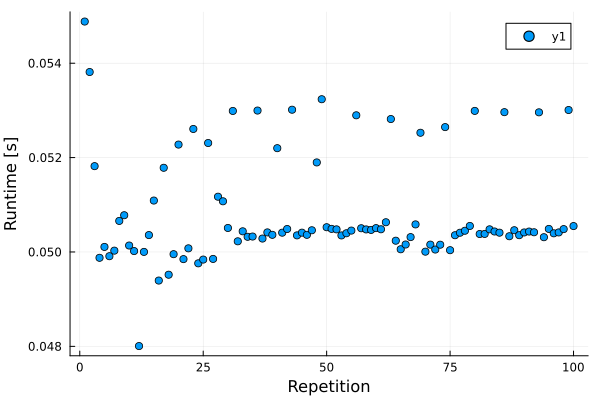

In [6]:
compute_pi_time = [@elapsed compute_pi_v1() for i in 1:100];
Plots.scatter(1:length(compute_pi_time), compute_pi_time, ylabel="Runtime [s]", xlabel="Repetition")

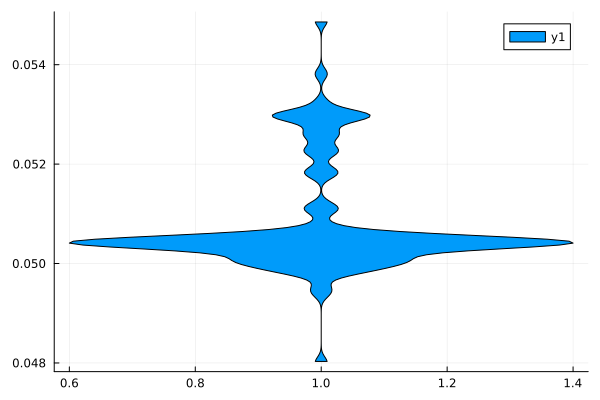

In [7]:
StatsPlots.violin(1:length(compute_pi_time), compute_pi_time)

In [8]:
@benchmark compute_pi_v1()

BenchmarkTools.Trial: 100 samples with 1 evaluation per sample.
 Range (min … max):  48.043 ms … 57.807 ms  ┊ GC (min … max):  9.48% … 22.96%
 Time  (median):     50.918 ms              ┊ GC (median):    13.73%
 Time  (mean ± σ):   50.393 ms ±  1.684 ms  ┊ GC (mean ± σ):  14.90% ±  2.71%

      ▁ █▅  ▁ ▁                       ▁ █▂▁                    
  ▃▁▁▁████▅▁███▃▁▅▁▃▁▁▁▁▁▁▁▁▃▁▃▁▁▁▁▁▃▃█▅███▆▅▃█▆▅▅▃▁▁▁▁▁▁▁▁▁▃ ▃
  48 ms           Histogram: frequency by time        53.4 ms <

 Memory estimate: 143.98 MiB, allocs estimate: 5241861.

# Type stability



## Unstable example

In [9]:
struct TUnstable
    v
end
example = TUnstable(3)
example.v

3

In [10]:
f_mul2(x) = 2 * x.v
@code_typed f_mul2(example)

CodeInfo(
1 ─ %1 =   builtin Base.getfield(x, :v)::Any
│   %2 =   dynamic (2 * %1)::Any
└──      return %2
) => Any

In [11]:
@code_warntype f_mul2(example)

MethodInstance for f_mul2(::TUnstable)
  from f_mul2(x) @ Main In[10]:1
Arguments
  #self#::Core.Const(Main.f_mul2)
  x::TUnstable
Body::Any
1 ─ %1 = Main.:*::Core.Const(*)
│   %2 = Base.getproperty(x, :v)::Any
│   %3 = (%1)(2, %2)::Any
└──      return %3



## Stable example

In [12]:
struct TStable
    v::Int64
end
example2 = TStable(3)
@code_warntype f_mul2(example2)

MethodInstance for f_mul2(::TStable)
  from f_mul2(x) @ Main In[10]:1
Arguments
  #self#::Core.Const(Main.f_mul2)
  x::TStable
Body::Int64
1 ─ %1 = Main.:*::Core.Const(*)
│   %2 = Base.getproperty(x, :v)::Int64
│   %3 = (%1)(2, %2)::Int64
└──      return %3



## Return type stability

In [13]:
function unstable_return_type(v)
    acc = 0
    for i in v
        acc = acc + i
    end
    return acc
end

unstable_return_type (generic function with 1 method)

In [14]:
Base.return_types(unstable_return_type, (Vector{Float64},))

1-element Vector{Any}:
 Union{Float64, Int64}

In [15]:
Base.return_types(unstable_return_type, (Vector{Float32},))

1-element Vector{Any}:
 Union{Float32, Int64}

In [16]:
typeof(unstable_return_type(rand(10)))

Float64

In [17]:
typeof(unstable_return_type(rand(0)))

Int64

In [18]:
function stable_return_type(v)
    acc = zero(eltype(v))
    for i in v
        acc = acc + i
    end
    return acc
end
Base.return_types(stable_return_type, (Vector{Float64},))

1-element Vector{Any}:
 Float64

In [19]:
@code_warntype compute_pi_v1()

MethodInstance for compute_pi_v1()
  from compute_pi_v1() @ Main In[4]:2
Arguments
  #self#::Core.Const(Main.compute_pi_v1)
Locals
  @_2::Any
  hits::Int64
  @_4::Int64
  i::Any
  y::Float64
  x::Float64
Body::Any
1 ─       (hits = 0)
│   %2  = Main.:(:)::Core.Const(Colon())
│   %3  = Main.N::Any
│   %4  = (%2)(1, %3)::Any
│         (@_2 = Base.iterate(%4))
│   %6  = @_2::Any
│   %7  = (%6 === nothing)::Bool
│   %8  = Base.not_int(%7)::Bool
└──       goto #6 if not %8
2 ┄ %10 = @_2::Any
│         (i = Core.getfield(%10, 1))
│   %12 = Core.getfield(%10, 2)::Any
│   %13 = Main.rand::Core.Const(rand)
│   %14 = Main.Uniform::Core.Const(Uniform)
│   %15 = (%14)(-1, 1)::Core.Const(Uniform{Float64}(a=-1.0, b=1.0))
│   %16 = (%13)(%15, 2)::Vector{Float64}
│   %17 = Base.indexed_iterate(%16, 1)::Core.PartialStruct(Tuple{Float64, Int64}, Any[Float64, Core.Const(2)])
│         (x = Core.getfield(%17, 1))
│         (@_4 = Core.getfield(%17, 2))
│   %20 = @_4::Core.Const(2)
│   %21 = Base.indexed_i

## Remove Type Ambiguity

In [20]:
function compute_pi_v2(N)
  hits = 0
  for i = 1:N
    x, y = rand(Uniform(-1,1),2)
    if sqrt(x^2 + y^2) <= 1.0
      hits += 1
    end
  end
  return 4.0 * hits / N
end

compute_pi_v2 (generic function with 1 method)

In [21]:
@code_warntype compute_pi_v2(2^20)

MethodInstance for compute_pi_v2(::Int64)
  from compute_pi_v2(N) @ Main In[20]:1
Arguments
  #self#::Core.Const(Main.compute_pi_v2)
  N::Int64
Locals
  @_3::Union{Nothing, Tuple{Int64, Int64}}
  hits::Int64
  @_5::Int64
  i::Int64
  y::Float64
  x::Float64
Body::Float64
1 ─       (hits = 0)
│   %2  = Main.:(:)::Core.Const(Colon())
│   %3  = (%2)(1, N)::Core.PartialStruct(UnitRange{Int64}, Any[Core.Const(1), Int64])
│         (@_3 = Base.iterate(%3))
│   %5  = @_3::Union{Nothing, Tuple{Int64, Int64}}
│   %6  = (%5 === nothing)::Bool
│   %7  = Base.not_int(%6)::Bool
└──       goto #6 if not %7
2 ┄ %9  = @_3::Tuple{Int64, Int64}
│         (i = Core.getfield(%9, 1))
│   %11 = Core.getfield(%9, 2)::Int64
│   %12 = Main.rand::Core.Const(rand)
│   %13 = Main.Uniform::Core.Const(Uniform)
│   %14 = (%13)(-1, 1)::Core.Const(Uniform{Float64}(a=-1.0, b=1.0))
│   %15 = (%12)(%14, 2)::Vector{Float64}
│   %16 = Base.indexed_iterate(%15, 1)::Core.PartialStruct(Tuple{Float64, Int64}, Any[Float64, Core

In [22]:
@benchmark compute_pi_v1()

BenchmarkTools.Trial: 98 samples with 1 evaluation per sample.
 Range (min … max):  49.972 ms … 58.797 ms  ┊ GC (min … max): 13.62% … 20.16%
 Time  (median):     50.191 ms              ┊ GC (median):    13.81%
 Time  (mean ± σ):   51.221 ms ±  1.731 ms  ┊ GC (mean ± σ):  15.43% ±  2.53%

   ▇█▁                                                         
  ▅███▆▃▁▁▃▃▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▄▃▆▆▅▃▃▁▁▃ ▁
  50 ms           Histogram: frequency by time          54 ms <

 Memory estimate: 143.98 MiB, allocs estimate: 5241861.

In [23]:
@benchmark compute_pi_v2(2^20)

BenchmarkTools.Trial: 214 samples with 1 evaluation per sample.
 Range (min … max):  22.651 ms … 26.510 ms  ┊ GC (min … max): 15.98% … 27.99%
 Time  (median):     22.753 ms              ┊ GC (median):    16.30%
 Time  (mean ± σ):   23.419 ms ±  1.430 ms  ┊ GC (mean ± σ):  18.57% ±  4.52%

  ▄█                                                           
  ███▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▇ ▂
  22.7 ms         Histogram: frequency by time        26.5 ms <

 Memory estimate: 80.00 MiB, allocs estimate: 2097152.

## Allocations depending on iterations

In [24]:
tries = 1:4000
times = zeros(length(tries))
allocn = zeros(length(tries))
allocs = zeros(length(tries))
for (i,v) in enumerate(tries)
    times[i] = @elapsed compute_pi_v2(v)
    allocn[i] = @allocations compute_pi_v2(v)
    allocs[i] = @allocated compute_pi_v2(v)
end

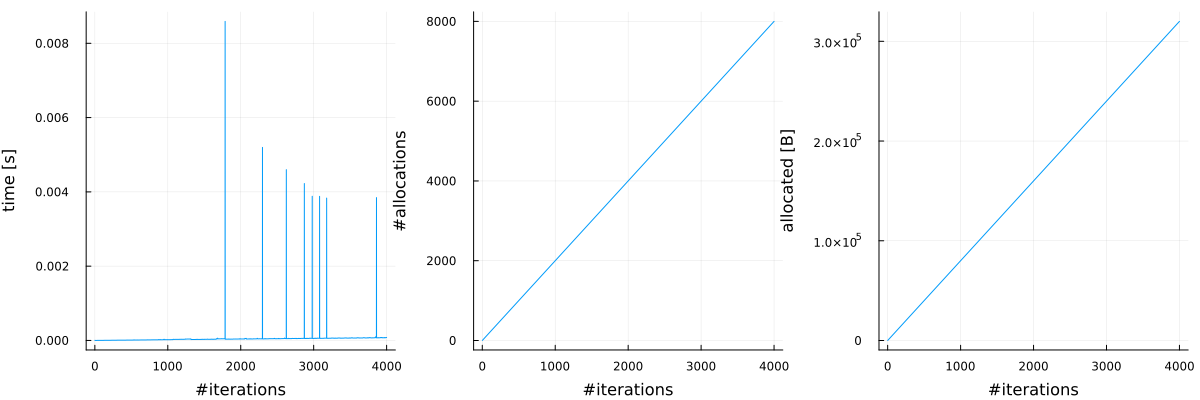

In [25]:
Plots.plot(
    Plots.plot(tries,times, xlabel="#iterations", ylabel="time [s]", label="", bottom_margin=20Plots.px, left_margin=20Plots.px), 
    Plots.plot(tries,allocn, xlabel="#iterations", ylabel="#allocations", label=""), 
    Plots.plot(tries,allocs, xlabel="#iterations", ylabel="allocated [B]", label=""),
    layout=(1,3), size=(1200,400)
)

## Profile Runtime

In [26]:
using Profile, ProfileSVG, FlameGraphs
Profile.clear()
Profile.@profile compute_pi_v2(2^20)
results_time = Profile.fetch()
Profile.print()

Overhead ╎ [+additional indent] Count File:Line  Function
 ╎13 ]8;;file://fpga1610/pc2/software/JUPYTER/cluster_setup/kernels/julia-1.12.6-1thread/depot/packages/IJulia/Vl5w1/src/eventloop.jl\@IJulia]8;;\]8;;file://fpga1610/pc2/software/JUPYTER/cluster_setup/kernels/julia-1.12.6-1thread/depot/packages/IJulia/Vl5w1/src/eventloop.jl\/src/eventloop.jl:71]8;;\  (::IJulia.var"#waitloop##2#waitloop##3"{IJuli…
 ╎ 13 ]8;;file://fpga1610/pc2/software/JUPYTER/cluster_setup/kernels/julia-1.12.6-1thread/depot/packages/IJulia/Vl5w1/src/eventloop.jl\@IJulia]8;;\]8;;file://fpga1610/pc2/software/JUPYTER/cluster_setup/kernels/julia-1.12.6-1thread/depot/packages/IJulia/Vl5w1/src/eventloop.jl\/…rc/eventloop.jl:26]8;;\  eventloop(socket::ZMQ.Socket, kernel::IJulia…
 ╎  13 ]8;;file://fpga1610/pc2/software/JUPYTER/cluster_setup/kernels/julia-1.12.6-1thread/depot/packages/IJulia/Vl5w1/src/execute_request.jl\@IJulia]8;;\]8;;file://fpga1610/pc2/software/JUPYTER/cluster_setup/kernels/julia-

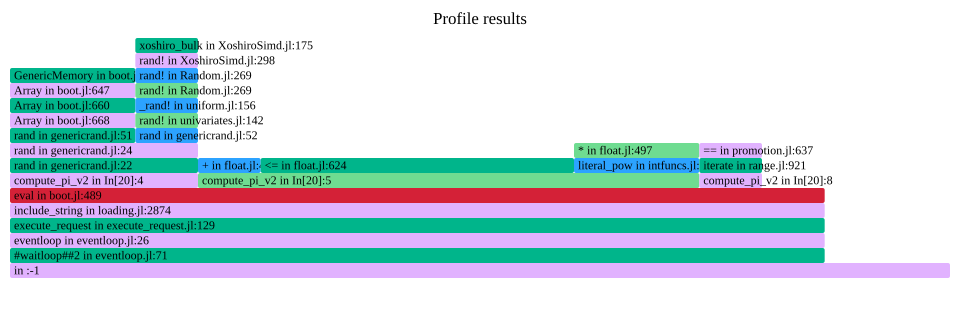

In [27]:
ProfileSVG.view(results_time)

## Profile Heap Allocations

In [28]:
Profile.Allocs.clear()
Profile.Allocs.@profile compute_pi_v2(2^20)
results_allocs = Profile.Allocs.fetch()

Profile.Allocs.AllocResults(Profile.Allocs.Alloc[Profile.Allocs.Alloc(Memory{Float64}, Base.StackTraces.StackFrame[maybe_record_alloc_to_profile at gc-alloc-profiler.h:43 [inlined], ...], 48), Profile.Allocs.Alloc(Memory{Float64}, Base.StackTraces.StackFrame[maybe_record_alloc_to_profile at gc-alloc-profiler.h:43 [inlined], ...], 48), Profile.Allocs.Alloc(Vector{Float64}, Base.StackTraces.StackFrame[maybe_record_alloc_to_profile at gc-alloc-profiler.h:43 [inlined], ...], 32), Profile.Allocs.Alloc(Memory{Float64}, Base.StackTraces.StackFrame[maybe_record_alloc_to_profile at gc-alloc-profiler.h:43 [inlined], ...], 48), Profile.Allocs.Alloc(Vector{Float64}, Base.StackTraces.StackFrame[maybe_record_alloc_to_profile at gc-alloc-profiler.h:43 [inlined], ...], 32), Profile.Allocs.Alloc(Memory{Float64}, Base.StackTraces.StackFrame[maybe_record_alloc_to_profile at gc-alloc-profiler.h:43 [inlined], ...], 48), Profile.Allocs.Alloc(Memory{Float64}, Base.StackTraces.StackFrame[maybe_record_alloc_to

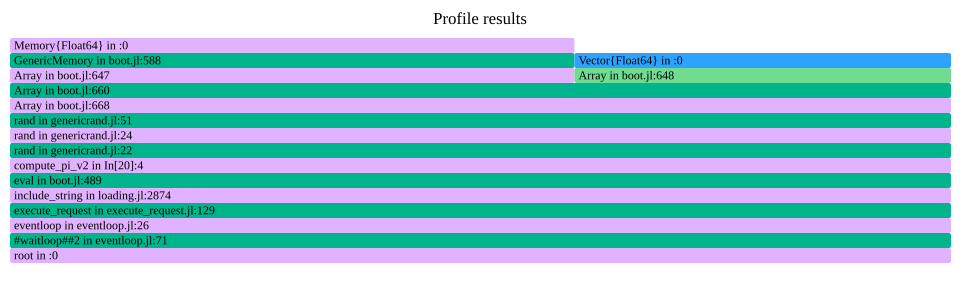

In [29]:
g = flamegraph(results_allocs)
ProfileSVG.FGConfig(g)

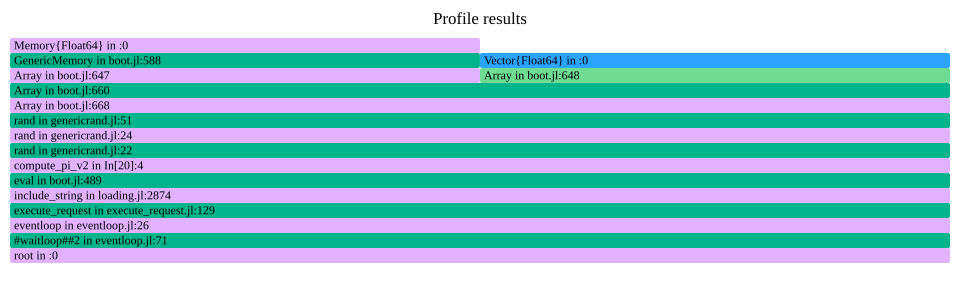

In [30]:
g = flamegraph(results_allocs, mode=:count)
ProfileSVG.FGConfig(g)

In [32]:
function compute_pi_v3(N)
  hits = 0
  for i = 1:N
    x, y = rand(Uniform(-1,1)), rand(Uniform(-1,1))
    if sqrt(x^2 + y^2) <= 1.0
      hits += 1
    end
  end
  return 4.0 * hits / N
end
@time compute_pi_v3(2^20)

  0.002084 seconds


3.1416702270507812

In [33]:
@benchmark compute_pi_v3(2^20)

BenchmarkTools.Trial: 2408 samples with 1 evaluation per sample.
 Range (min … max):  2.063 ms …  2.910 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     2.076 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   2.077 ms ± 17.164 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

                                  ▁█▄▇▃▁▁▃   ▁                
  ▂▁▁▂▁▁▁▁▁▂▂▂▂▁▂▂▁▂▂▂▂▂▂▂▂▃▃▃▄▄▅▆████████▇███▇▆▅▄▃▃▂▃▃▂▂▂▂▂ ▃
  2.06 ms        Histogram: frequency by time        2.08 ms <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [34]:
#tries = 1:4000
times_v3 = zeros(length(tries))
for (i,v) in enumerate(tries)
    times_v3[i] = @elapsed compute_pi_v3(v)
end

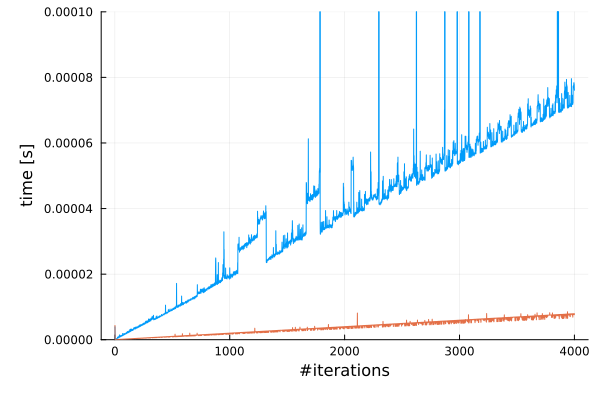

In [35]:
p = Plots.plot(tries,times, xlabel="#iterations", ylabel="time [s]", label="", bottom_margin=20Plots.px, left_margin=20Plots.px, ylim=(0,0.0001))
Plots.plot!(p, tries,times_v3, xlabel="#iterations", ylabel="time [s]", label="", bottom_margin=20Plots.px, left_margin=20Plots.px)

## Heap allocation decisions
Allocation decision depends on concrete Julia version

Requirements for stack usage:
* Data fits on stack
* Data is referenced only while allocation persists (function call is going on)
* Data has fixed size known at compile time
* Data is immutable

Julia will use heap allocations if it can't proof safe stack usage.

⮕ Use tuples or StaticArrays instead of arrays.

# Memory Layout
How many floating point operations are performed?
Element-wise matrix addition: m * n elements -> 1 addition per element

In [36]:
function mat_add!(c::Matrix, a::Matrix, b::Matrix)
	for row in 1:size(a,1)
		for col in 1:size(a,2)
			c[row,col] = a[row,col] + b[row,col]
		end
	end
	return c
end

mat_add! (generic function with 1 method)

## Measure using LIKWID
Only on exclusive nodes!

In [37]:
using LIKWID

In [38]:
LIKWID.PerfMon.supported_groups()

Dict{String, LIKWID.GroupInfoCompact} with 20 entries:
  "L2CACHE"    => L2CACHE => L2 cache miss rate/ratio (experimental)
  "MEM"        => MEM => Main memory read bandwidth in MBytes/s
  "BRANCH"     => BRANCH => Branch prediction miss rate/ratio
  "FLOPS_SP"   => FLOPS_SP => Single-precision MFLOP/s
  "FLOPS_ANY"  => FLOPS_ANY => Any Floating-point MFLOP/s
  "DIVIDE"     => DIVIDE => Divide unit information
  "CPI"        => CPI => Cycles per instruction
  "L3CACHE"    => L3CACHE => L3 cache miss rate/ratio (experimental)
  "CACHE"      => CACHE => Data cache miss rate/ratio
  "ROOF_MEM"   => ROOF_MEM => Roof
  "ICACHE"     => ICACHE => Instruction cache miss rate/ratio
  "TLB"        => TLB => TLB miss rate/ratio
  "CLOCK"      => CLOCK => Cycles per instruction
  "TMA"        => TMA => Pipeline Utilization Analysis
  "FLOPS_DP"   => FLOPS_DP => Double-precision MFLOP/s
  "ENERGY"     => ENERGY => Power and Energy consumption
  "FLOPS_BF16" => FLOPS_BF16 => Bfloat16 MFLOP/s
  "DAT

In [39]:
function measure_mat_add()
    A = rand(1000, 1000) # 10^6 elements
    B = rand(1000, 1000)
    C = zeros(1000, 1000)
    @perfmon "FLOPS_ANY" mat_add!(C, A, B)
end

measure_mat_add (generic function with 1 method)

In [40]:
measure_mat_add()


Group: FLOPS_ANY
┌───────────────────────────────┬───────────┐
│                         Event │  Thread 1 │
├───────────────────────────────┼───────────┤
│              ACTUAL_CPU_CLOCK │ 8.69473e6 │
│                 MAX_CPU_CLOCK │ 7.06904e6 │
│          RETIRED_INSTRUCTIONS │ 2.75525e6 │
│           CPU_CLOCKS_UNHALTED │  8.5906e6 │
│ RETIRED_SSE_AVX_FLOPS_ALL_ANY │     1.0e6 │
└───────────────────────────────┴───────────┘
┌──────────────────────┬────────────┐
│               Metric │   Thread 1 │
├──────────────────────┼────────────┤
│  Runtime (RDTSC) [s] │ 0.00269785 │
│ Runtime unhalted [s] │ 0.00334918 │
│          Clock [MHz] │    3193.11 │
│                  CPI │     3.1179 │
│         DP [MFLOP/s] │    370.666 │
└──────────────────────┴────────────┘


(OrderedDict("FLOPS_ANY" => [OrderedDict("Runtime (RDTSC) [s]" => 0.0026978483792214477, "Runtime unhalted [s]" => 0.0033491790531868285, "Clock [MHz]" => 3193.111180491151, "CPI" => 3.1179025496778876, "DP [MFLOP/s]" => 370.66575264269767)]), OrderedDict("FLOPS_ANY" => [OrderedDict("ACTUAL_CPU_CLOCK" => 8.694734e6, "MAX_CPU_CLOCK" => 7.069036e6, "RETIRED_INSTRUCTIONS" => 2.75525e6, "CPU_CLOCKS_UNHALTED" => 8.590601e6, "RETIRED_SSE_AVX_FLOPS_ALL_ANY" => 1.0e6)]))

In [41]:
function mat_add_col!(c::Matrix, a::Matrix, b::Matrix)
    for row in 1:size(a,1)
        for col in 1:size(a,2)
            c[row,col] = a[row,col] + b[row,col]
        end
    end
    return c
end

function mat_add_row!(c::Matrix, a::Matrix, b::Matrix)
    for col in 1:size(a,2)
        for row in 1:size(a,1)
            c[row,col] = a[row,col] + b[row,col]
        end
    end
    return c
end

mat_add_row! (generic function with 1 method)

In [53]:
s = 2^13
A = rand(s, s)
B = rand(s, s)
C = zeros(s, s)
@benchmark mat_add_col!(C, A, B)

BenchmarkTools.Trial: 3 samples with 1 evaluation per sample.
 Range (min … max):  1.809 s …  1.812 s  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     1.810 s             ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.810 s ± 1.405 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █                █                                     █  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  1.81 s        Histogram: frequency by time        1.81 s <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [54]:
@benchmark mat_add_row!(C, A, B)

BenchmarkTools.Trial: 157 samples with 1 evaluation per sample.
 Range (min … max):  31.720 ms …  35.181 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     31.781 ms               ┊ GC (median):    0.00%
 Time  (mean ± σ):   31.856 ms ± 424.756 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █▁                                                            
  ███▆▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂ ▂
  31.7 ms         Histogram: frequency by time         34.5 ms <

 Memory estimate: 0 bytes, allocs estimate: 0.

In [55]:
LIKWID.@perfmon "L2CACHE" mat_add_col!(C, A, B)


Group: L2CACHE
┌────────────────────────────────┬───────────┐
│                          Event │  Thread 1 │
├────────────────────────────────┼───────────┤
│     REQUESTS_TO_L2_GRP1_RD_ANY │ 8.60093e8 │
│            L2_PF_HIT_IN_L2_ALL │ 1.57938e7 │
│            L2_PF_HIT_IN_L3_ALL │ 5.92425e7 │
│           L2_PF_MISS_IN_L3_ALL │ 2.61688e7 │
│ CORE_TO_L2_CACHE_REQUESTS_HITS │ 4.32755e8 │
│           RETIRED_INSTRUCTIONS │ 1.41568e8 │
└────────────────────────────────┴───────────┘
┌──────────────────────┬─────────────┐
│               Metric │    Thread 1 │
├──────────────────────┼─────────────┤
│  Runtime (RDTSC) [s] │     1.81439 │
│ Runtime unhalted [s] │ 3.85196e-10 │
│      L2 request rate │     6.79035 │
│         L2 miss rate │     3.62192 │
│        L2 miss ratio │    0.533392 │
│          L2 accesses │   9.61298e8 │
│              L2 hits │   4.48549e8 │
│            L2 misses │   5.12749e8 │
└──────────────────────┴─────────────┘


(OrderedDict("L2CACHE" => [OrderedDict("Runtime (RDTSC) [s]" => 1.8143930908313741, "Runtime unhalted [s]" => 3.8519626399e-10, "L2 request rate" => 6.790346410123828, "L2 miss rate" => 3.6219181715269113, "L2 miss ratio" => 0.5333922531738499, "L2 accesses" => 9.61298144e8, "L2 hits" => 4.48549161e8, "L2 misses" => 5.12748983e8)]), OrderedDict("L2CACHE" => [OrderedDict("REQUESTS_TO_L2_GRP1_RD_ANY" => 8.60093126e8, "L2_PF_HIT_IN_L2_ALL" => 1.5793764e7, "L2_PF_HIT_IN_L3_ALL" => 5.9242484e7, "L2_PF_MISS_IN_L3_ALL" => 2.616877e7, "CORE_TO_L2_CACHE_REQUESTS_HITS" => 4.32755397e8, "RETIRED_INSTRUCTIONS" => 1.41568351e8)]))

In [56]:
LIKWID.@perfmon "L2CACHE" mat_add_row!(C, A, B)


Group: L2CACHE
┌────────────────────────────────┬───────────┐
│                          Event │  Thread 1 │
├────────────────────────────────┼───────────┤
│     REQUESTS_TO_L2_GRP1_RD_ANY │ 2.06928e7 │
│            L2_PF_HIT_IN_L2_ALL │ 4.50321e6 │
│            L2_PF_HIT_IN_L3_ALL │   33894.0 │
│           L2_PF_MISS_IN_L3_ALL │ 1.07846e6 │
│ CORE_TO_L2_CACHE_REQUESTS_HITS │ 1.08894e6 │
│           RETIRED_INSTRUCTIONS │ 2.91559e7 │
└────────────────────────────────┴───────────┘
┌──────────────────────┬─────────────┐
│               Metric │    Thread 1 │
├──────────────────────┼─────────────┤
│  Runtime (RDTSC) [s] │   0.0322156 │
│ Runtime unhalted [s] │ 3.85196e-10 │
│      L2 request rate │    0.902335 │
│         L2 miss rate │    0.710533 │
│        L2 miss ratio │    0.787438 │
│          L2 accesses │   2.63083e7 │
│              L2 hits │   5.59215e6 │
│            L2 misses │   2.07162e7 │
└──────────────────────┴─────────────┘


(OrderedDict("L2CACHE" => [OrderedDict("Runtime (RDTSC) [s]" => 0.032215551336399015, "Runtime unhalted [s]" => 3.8519626399e-10, "L2 request rate" => 0.9023351126902414, "L2 miss rate" => 0.7105330689701677, "L2 miss ratio" => 0.7874381246804959, "L2 accesses" => 2.6308349e7, "L2 hits" => 5.592152e6, "L2 misses" => 2.0716197e7)]), OrderedDict("L2CACHE" => [OrderedDict("REQUESTS_TO_L2_GRP1_RD_ANY" => 2.069278e7, "L2_PF_HIT_IN_L2_ALL" => 4.50321e6, "L2_PF_HIT_IN_L3_ALL" => 33894.0, "L2_PF_MISS_IN_L3_ALL" => 1.078465e6, "CORE_TO_L2_CACHE_REQUESTS_HITS" => 1.088942e6, "RETIRED_INSTRUCTIONS" => 2.9155852e7)]))

## Memory Layout of Matrices

### Matrix data structure
|||||
|-|-|-|-|
|a11|a12|a13|a14|
|a21|a22|a23|a24|
|a31|a32|a33|a34|
|a41|a42|a43|a44|

### Row-major order in memory (C, Pascal)
|||||||||||
|-|-|-|-|-|-|-|-|-|-|
||a11|a12|a13|a14|a21|a22|a23|a24||

### Column-major order in memory (Julia, Fortran, Matlab)
|||||||||||
|-|-|-|-|-|-|-|-|-|-|
||a11|a21|a31|a41|a12|a22|a32|a42||

# SIMD

In [46]:
function vector_dot(B, C)
    a = zero(eltype(B))
    for i in eachindex(B,C)
        @inbounds a += B[i] * C[i]
    end
    return a
end

function vector_dot_macro(B, C)
    a = zero(eltype(B))
    @simd for i in eachindex(B,C)
        @inbounds a += B[i] * C[i]
    end
    return a
end

using LoopVectorization
function vector_dot_turbo(B, C)
    a = zero(eltype(B))
    @turbo for i in eachindex(B,C)
        @inbounds a += B[i] * C[i]
    end
    return a
end

vector_dot_turbo (generic function with 1 method)

In [1]:
B = rand(2^20);
C = rand(2^20);

In [48]:
@benchmark vector_dot(B, C)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  468.456 μs …  2.692 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     469.798 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   470.883 μs ± 30.773 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

        ▂▆█▆▄         ▃                                         
  ▁▁▁▂▃▆█████▇▄▂▂▂▂▄▆███▇▄▃▂▂▃▃▃▃▃▃▃▃▂▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▃
  468 μs          Histogram: frequency by time          475 μs <

 Memory estimate: 16 bytes, allocs estimate: 1.

In [49]:
@benchmark vector_dot_macro(B, C)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  119.119 μs … 157.488 μs  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     119.910 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   120.232 μs ±   1.218 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

           ▄▇█▅▃                                                 
  ▂▂▃▃▄▅▅▆███████▆▄▃▃▂▂▂▂▂▂▂▂▁▂▂▁▁▁▂▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂ ▃
  119 μs           Histogram: frequency by time          123 μs <

 Memory estimate: 16 bytes, allocs estimate: 1.

In [50]:
@benchmark vector_dot_turbo(B, C)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  125.039 μs …  3.710 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     147.181 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   147.826 μs ± 36.511 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

                          ▁▁▁▁▁▁▁▁▁ ▁▁▁                ▄▅█      
  ▂▁▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▆▇▇▇█▇██████████████████▇▇██▇▇▇▇▆▆▇███▇▄▄▄ ▅
  125 μs          Histogram: frequency by time          161 μs <

 Memory estimate: 16 bytes, allocs estimate: 1.

In [3]:
using LinearAlgebra; @benchmark dot(B, C)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  29.144 μs …   9.682 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     33.761 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   71.347 μs ± 583.982 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

             ▁▂▂▅▄▆▆▇▆█▇▇▆▅▆▄▂▁▁                                
  ▁▁▁▂▂▂▃▄▅▆████████████████████▆▅▅▃▂▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▄
  29.1 μs         Histogram: frequency by time         42.5 μs <

 Memory estimate: 16 bytes, allocs estimate: 1.

In [58]:
LinearAlgebra.BLAS.get_config()

LinearAlgebra.BLAS.LBTConfig
Libraries: 
└ [ILP64] libopenblas64_.so